In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [70]:
config_file = Path("config/buffaloshooting.yaml")
cameo_data_file = "EventRootCode.csv"


data_dir = Path(f"output/{config_file.stem}/cameo_info/")

df = pd.read_csv(data_dir.joinpath(cameo_data_file))
df = df.sort_values('day')
# df = df.set_index('day')
# df = df.sort_index()
df.columns

Index(['day', 'EventRootCode_counts', 'count'], dtype='object')

In [71]:
def make_normalized_columns(df, col_name, day_col='day'):
    # Normalized counts for each group (event code)
    df['normalized_count'] = df.groupby(col_name)['count'].transform(lambda x: x/x.sum())
    df_norm = df.groupby(col_name, as_index=False).rolling(window=5, min_periods=1, on='day').mean()
    
    return df_norm

# code_sums = df.groupby('EventRootCode_counts')['count'].sum()

df = make_normalized_columns(df, 'EventRootCode_counts')


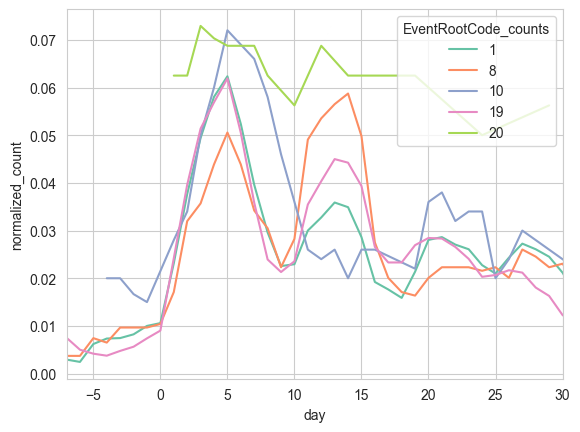

In [73]:
sns.set_style("whitegrid")

plt.xlim(-7,30)

df_ = df[df['EventRootCode_counts'].isin({1,8, 10, 19, 20})]
sns.lineplot(data=df_, x='day', y='normalized_count', hue='EventRootCode_counts', palette='Set2');